# Load cleaned data

In [74]:
import pandas as pd
import matplotlib.pyplot as plt

In [75]:
# load data from weather_validated.csv

df = pd.read_csv(
    './weather_validated.csv',
    parse_dates=[
        'last_updated',
        'sunrise',
        'sunset',
        'moonrise',
        'moonset'
        ]
)
df.shape

(144229, 41)

In [76]:
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 144229 entries, 0 to 144228
Data columns (total 41 columns):
 #   Column                        Non-Null Count   Dtype         
---  ------                        --------------   -----         
 0   country                       144229 non-null  str           
 1   location_name                 144229 non-null  str           
 2   latitude                      144229 non-null  float64       
 3   longitude                     144229 non-null  float64       
 4   timezone                      144229 non-null  str           
 5   last_updated_epoch            144229 non-null  int64         
 6   last_updated                  144229 non-null  datetime64[us]
 7   temperature_celsius           144229 non-null  float64       
 8   temperature_fahrenheit        144229 non-null  float64       
 9   condition_text                144229 non-null  str           
 10  wind_mph                      144229 non-null  float64       
 11  wind_kph                

,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,2024-05-16 13:15:00,26.6,79.8,Partly Cloudy,...,8.4,26.6,1,1,2026-05-29 04:50:00,2026-05-29 18:50:00,2026-05-29 12:12:00,2026-05-29 01:11:00,Waxing Gibbous,55
1,Albania,Tirana,41.33,19.82,Europe/Tirane,1715849100,2024-05-16 10:45:00,19.0,66.2,Partly cloudy,...,1.1,2.0,1,1,2026-05-29 05:21:00,2026-05-29 19:54:00,2026-05-29 12:58:00,2026-05-29 02:14:00,Waxing Gibbous,55
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,1715849100,2024-05-16 09:45:00,23.0,73.4,Sunny,...,10.4,18.4,1,1,2026-05-29 05:40:00,2026-05-29 19:50:00,2026-05-29 13:15:00,2026-05-29 02:14:00,Waxing Gibbous,55
3,Andorra,Andorra La Vella,42.50,1.52,Europe/Andorra,1715849100,2024-05-16 10:45:00,6.3,43.3,Light drizzle,...,0.7,0.9,1,1,2026-05-29 06:31:00,2026-05-29 21:11:00,2026-05-29 14:12:00,2026-05-29 03:31:00,Waxing Gibbous,55
4,Angola,Luanda,-8.84,13.23,Africa/Luanda,1715849100,2024-05-16 09:45:00,26.0,78.8,Partly cloudy,...,183.4,262.3,5,10,2026-05-29 06:12:00,2026-05-29 17:55:00,2026-05-29 13:17:00,2026-05-29 00:38:00,Waxing Gibbous,55


In [77]:
df.select_dtypes(include='number').columns

Index(['latitude', 'longitude', 'last_updated_epoch', 'temperature_celsius',
       'temperature_fahrenheit', 'wind_mph', 'wind_kph', 'wind_degree',
       'pressure_mb', 'pressure_in', 'precip_mm', 'precip_in', 'humidity',
       'cloud', 'feels_like_celsius', 'feels_like_fahrenheit', 'visibility_km',
       'visibility_miles', 'uv_index', 'gust_mph', 'gust_kph',
       'air_quality_Carbon_Monoxide', 'air_quality_Ozone',
       'air_quality_Nitrogen_dioxide', 'air_quality_Sulphur_dioxide',
       'air_quality_PM2.5', 'air_quality_PM10', 'air_quality_us-epa-index',
       'air_quality_gb-defra-index', 'moon_illumination'],
      dtype='str')

In [78]:
df.select_dtypes(exclude='number').columns

Index(['country', 'location_name', 'timezone', 'last_updated',
       'condition_text', 'wind_direction', 'sunrise', 'sunset', 'moonrise',
       'moonset', 'moon_phase'],
      dtype='str')

In [79]:
target_variable = 'temperature_celsius'

numerical_features = df.select_dtypes(include='number').columns.tolist()

categorical_features = df.select_dtypes(exclude='number').columns.tolist()

temporal_features = df.select_dtypes(
    include='datetime'
).columns.tolist()

# Correlation Analysis

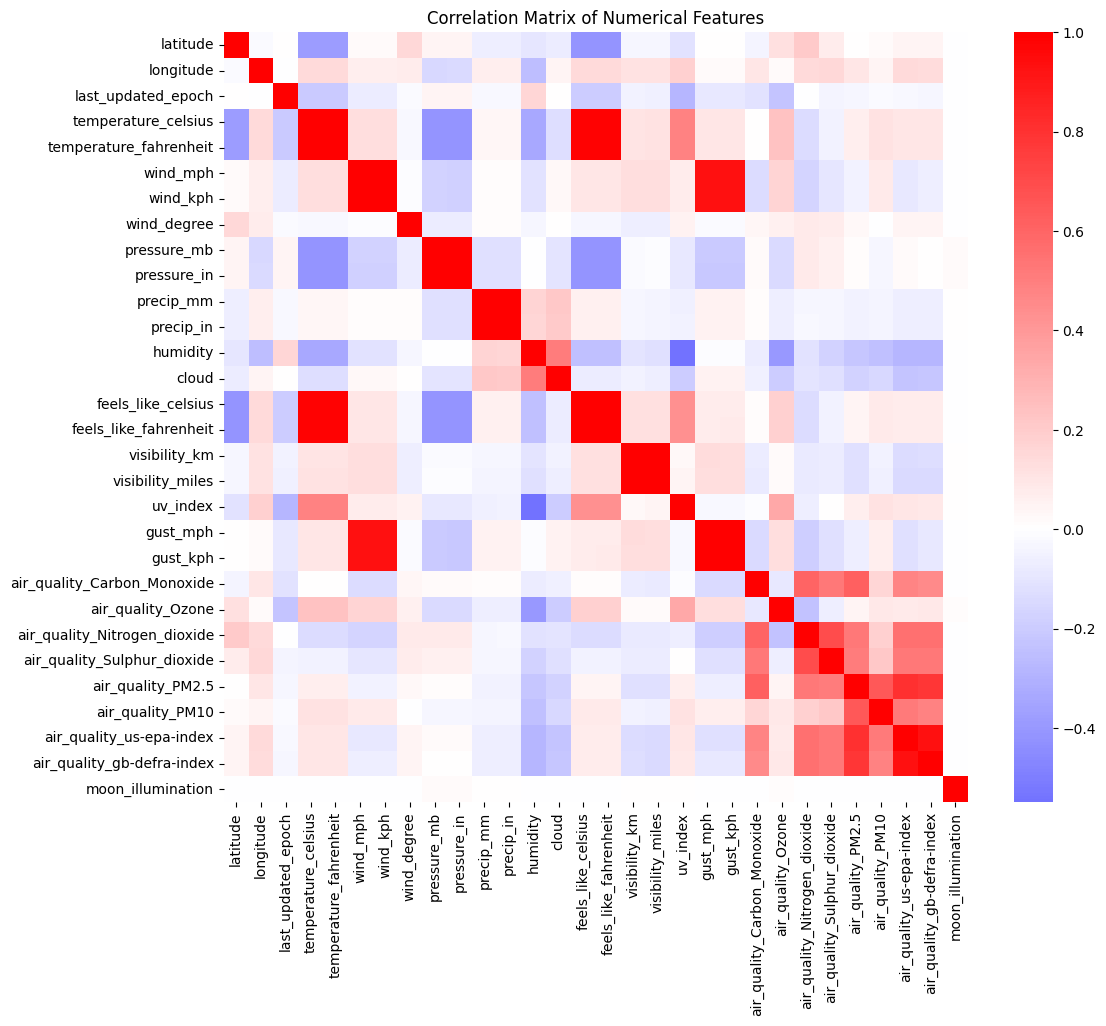

In [80]:
# checking correlation between numerical features

correlation_matrix = df[numerical_features].corr()

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 10))

sns.heatmap(
    correlation_matrix,
    cmap='bwr',
    center=0
)

plt.title('Correlation Matrix of Numerical Features')

plt.show()

In [81]:
temp_corr = correlation_matrix[
    'temperature_celsius'
].sort_values(ascending=False)

display(temp_corr.head(5))

temperature_celsius       1.000000
temperature_fahrenheit    0.999997
feels_like_celsius        0.983771
feels_like_fahrenheit     0.983768
uv_index                  0.488740
Name: temperature_celsius, dtype: float64

In [82]:
temp_corr = correlation_matrix[
    'temperature_celsius'
].sort_values(ascending=True)

display(temp_corr.head(5))

pressure_in          -0.419784
pressure_mb          -0.418776
latitude             -0.383990
humidity             -0.338945
last_updated_epoch   -0.208878
Name: temperature_celsius, dtype: float64

In [83]:
# Most highly correlated features are due to redundant measurements in different units
# Drop one of each pair of redundant features

redundant_feature_pairs = {
    'temperature': [
        'temperature_celsius',
        'temperature_fahrenheit'
    ],
    
    'wind_speed': [
        'wind_mph',
        'wind_kph'
    ],
    
    'pressure': [
        'pressure_mb',
        'pressure_in'
    ],
    
    'precipitation': [
        'precip_mm',
        'precip_in'
    ],
    
    'feels_like_temperature': [
        'feels_like_celsius',
        'feels_like_fahrenheit'
    ],
    
    'visibility': [
        'visibility_km',
        'visibility_miles'
    ],

    'gust_speed': [
        'gust_mph',
        'gust_kph'
    ]
}

columns_to_drop = [
    features[1]
    for features in redundant_feature_pairs.values()
]

df = df.drop(columns=columns_to_drop)

print(columns_to_drop)
print(df.shape)

['temperature_fahrenheit', 'wind_kph', 'pressure_in', 'precip_in', 'feels_like_fahrenheit', 'visibility_miles', 'gust_kph']
(144229, 34)


In [84]:
df.columns

Index(['country', 'location_name', 'latitude', 'longitude', 'timezone',
       'last_updated_epoch', 'last_updated', 'temperature_celsius',
       'condition_text', 'wind_mph', 'wind_degree', 'wind_direction',
       'pressure_mb', 'precip_mm', 'humidity', 'cloud', 'feels_like_celsius',
       'visibility_km', 'uv_index', 'gust_mph', 'air_quality_Carbon_Monoxide',
       'air_quality_Ozone', 'air_quality_Nitrogen_dioxide',
       'air_quality_Sulphur_dioxide', 'air_quality_PM2.5', 'air_quality_PM10',
       'air_quality_us-epa-index', 'air_quality_gb-defra-index', 'sunrise',
       'sunset', 'moonrise', 'moonset', 'moon_phase', 'moon_illumination'],
      dtype='str')

In [85]:
numerical_features = df.select_dtypes(include='number').columns.tolist()

geographical_features = [
    'country',
    'location_name',
    'latitude',
    'longitude',
    'timezone'
]

weather_features = [
    'temperature_celsius',
    'condition_text',
    'wind_mph',
    'wind_degree',
    'wind_direction',
    'pressure_mb',
    'precip_mm',
    'humidity',
    'cloud',
    'feels_like_celsius',
    'visibility_km',
    'uv_index',
    'gust_mph'
]

air_quality_features = [
    'air_quality_Carbon_Monoxide',
    'air_quality_Ozone',
    'air_quality_Nitrogen_dioxide',
    'air_quality_Sulphur_dioxide',
    'air_quality_PM2.5',
    'air_quality_PM10',
    'air_quality_us-epa-index',
    'air_quality_gb-defra-index'
]

astronomical_features = [
    'moon_phase',
    'moon_illumination'
]


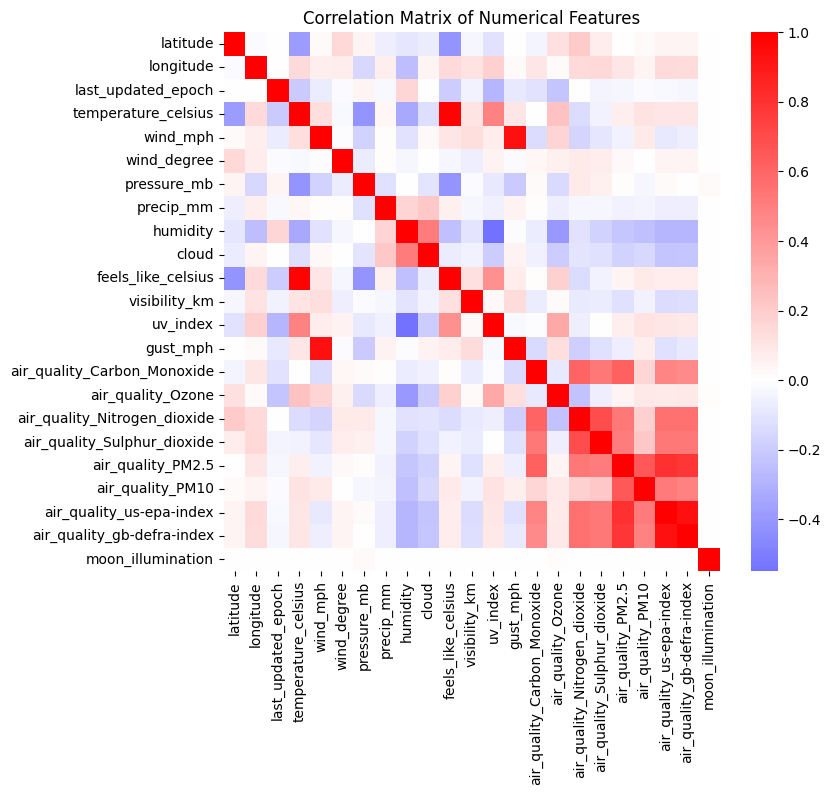

In [86]:
# checking correlation between numerical features after removing redundant features

correlation_matrix = df[numerical_features].corr()

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 7))

sns.heatmap(
    correlation_matrix,
    cmap='bwr',
    center=0
)

plt.title('Correlation Matrix of Numerical Features')

plt.show()

Text(0.5, 1.0, 'Temperature vs Feels Like Temperature')

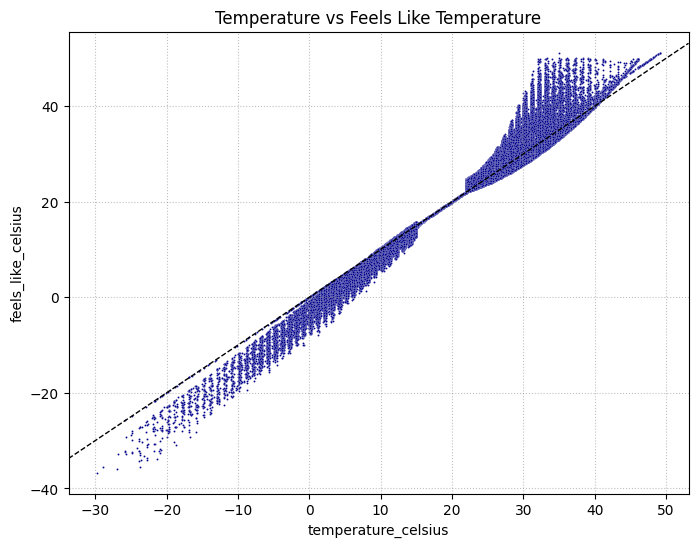

In [87]:
# plot temperature_celsius vs feels_like_celsius

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x='temperature_celsius',
    y='feels_like_celsius',
    s=2,
    color='darkblue'
)
plt.grid(True, which='both', linestyle=':', alpha=0.5, color='gray')
plt.axline((0, 0), slope=1, color='black', linestyle='--', linewidth=1, label='x=y')

plt.title('Temperature vs Feels Like Temperature')

Although feels-like temperature exhibited strong correlation with actual temperature, exploratory analysis showed meaningful dispersion at temperature extremes, likely reflecting humidity and wind-chill effects. Therefore, the feature was retained during exploratory analysis and initial modeling preparation.

In [88]:
wind_corr = correlation_matrix[
    'wind_mph'
].sort_values(ascending=False)

display(wind_corr.head(5))

wind_mph               1.000000
gust_mph               0.930631
air_quality_Ozone      0.169436
visibility_km          0.127021
temperature_celsius    0.126194
Name: wind_mph, dtype: float64

Text(0.5, 1.0, 'Wind Speed vs Gust Speed')

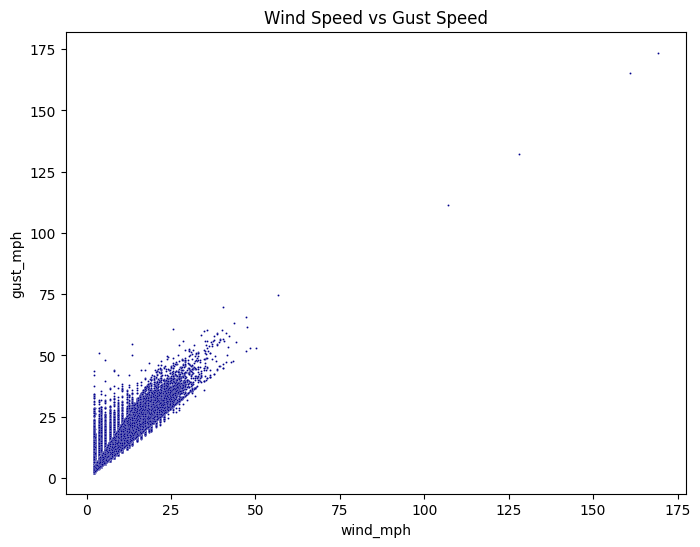

In [89]:
# plot wind_mph vs gust_mph

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x='wind_mph',
    y='gust_mph',
    color='darkblue',
    s=2
)

plt.title('Wind Speed vs Gust Speed')

Wind speed and gust speed exhibited strong positive correlation (r ≈ 0.93). However, the scatterplot revealed substantial variability in gust intensity for a given sustained wind speed, indicating that gust measurements contain additional meteorological information rather than representing simple duplicates.

## Notes
- Most highly correlated features are so due to redundant measurements in different units, and these have been removed.

- While not redundant and highly informative, both `feels_like_celsius` and `gust_mph` has very strong positive correlations will other features in the dataset, and will affect prediction/forecasting of `temperature_celsius` adversely, these will be removed for modelling.

# Anamoly Detection

- Multivariate anomaly detection
- Univariate anomaly/outlier detection and validation already completed in `global_weather_cleaning_preprocessing_validation.ipynb`

## Isolation Forest

In [90]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Features for multivariate anomaly detection - Numerical features
X = df[numerical_features]

# Scale features because ranges differ greatly
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Isolation Forest
iso_forest = IsolationForest(
    n_estimators=100,
    contamination=0.01,   # assumes ~1% anomalies
    random_state=42
)

anomaly_labels = iso_forest.fit_predict(X_scaled)

# Store results back into dataframe
df_anomaly = df.copy()
df_anomaly.loc[X.index, 'anomaly_label'] = anomaly_labels
df_anomaly.loc[X.index, 'anomaly_score'] = iso_forest.decision_function(X_scaled)

# -1 = anomaly, 1 = normal
display(df_anomaly['anomaly_label'].value_counts())
display(df_anomaly['anomaly_score'].describe())

anomaly_label
 1.0    142786
-1.0      1443
Name: count, dtype: int64

count    144229.000000
mean          0.160942
std           0.044623
min          -0.120090
25%           0.142490
50%           0.172164
75%           0.191778
max           0.231479
Name: anomaly_score, dtype: float64

### PCA Scatter Plot - 2D

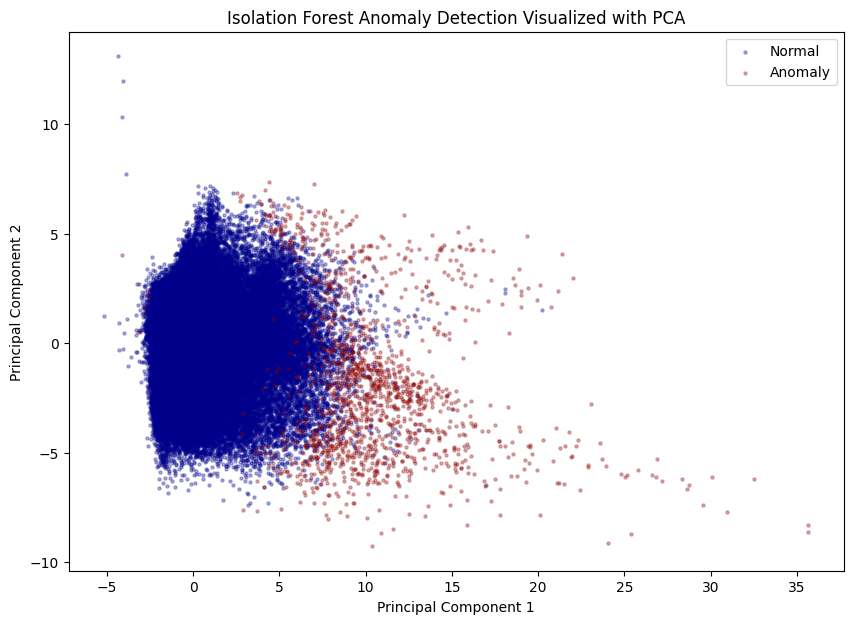

In [91]:
# Reduce scaled feature space to 2D for visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    X_pca,
    columns=['PC1', 'PC2'],
    index=X.index
)

pca_df['anomaly_label'] = anomaly_labels

plt.figure(figsize=(10, 7))

normal = pca_df[pca_df['anomaly_label'] == 1]
anomalies = pca_df[pca_df['anomaly_label'] == -1]

plt.scatter(
    normal['PC1'],
    normal['PC2'],
    s=5,
    alpha=0.3,
    label='Normal',
    color='darkblue'
)

plt.scatter(
    anomalies['PC1'],
    anomalies['PC2'],
    s=5,
    alpha=0.3,
    label='Anomaly',
    color='darkred'
)

plt.title('Isolation Forest Anomaly Detection Visualized with PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()

plt.show()

### SHAP Explantion for anamolies

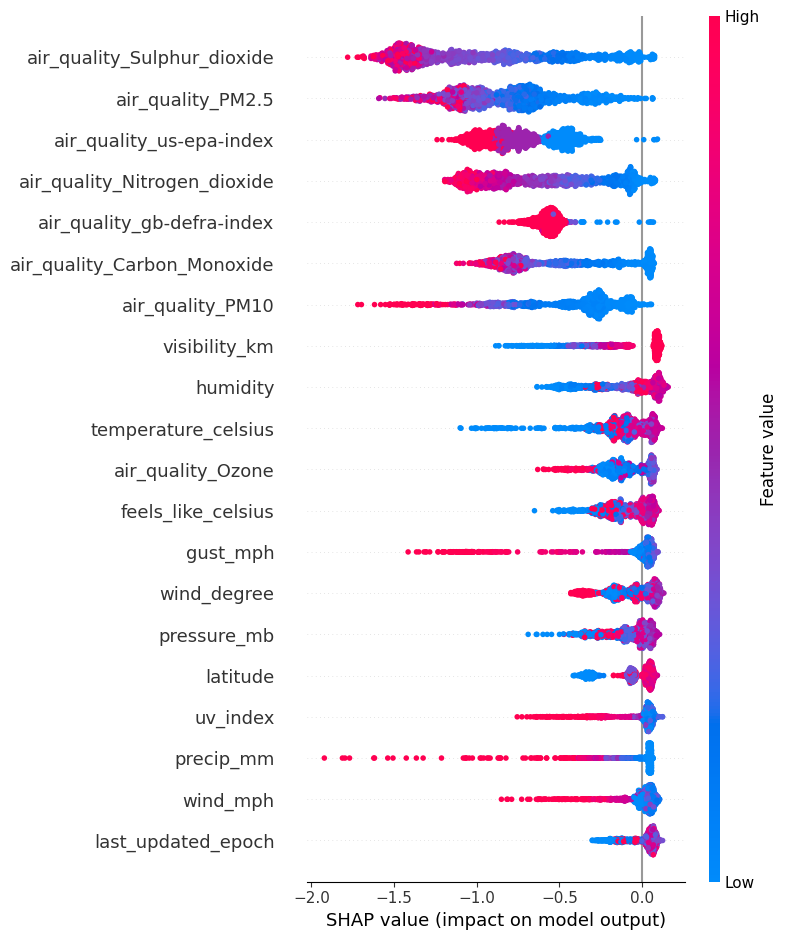

In [92]:
# Convert X_scaled back to pd df from ndarray
X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=X.columns,
    index=X.index
)

# Get anomaly rows
anomaly_mask = df_anomaly.loc[X.index, 'anomaly_label'] == -1
X_anomaly_scaled = X_scaled_df.loc[anomaly_mask]

# SHAP explanation
import shap

explainer = shap.TreeExplainer(iso_forest)
shap_values = explainer.shap_values(X_anomaly_scaled)

shap.summary_plot(
    shap_values,
    X_anomaly_scaled,
    feature_names=X.columns
)

## Notes
- Most anomalies in this weather dataset are driven by unusual air-quality conditions rather than temperature, humidity, wind, or precipitation.
- High pollutant concentrations contribute strongly toward anomaly classification.
- Low visibility is a strong contributor to observations classified as anomalous by the Isolation Forest model.
- Unusual temperatures exist, but they are not the primary reason observations are flagged as anomalies.

# Removing anamolous data, redundant features

In [93]:
df_anomaly[df_anomaly['anomaly_label'] == -1][
    [
        'country',
        'location_name',
        'last_updated',
        'anomaly_score'
    ] + numerical_features
].sort_values('anomaly_score').head(20)

,country,location_name,last_updated,anomaly_score,latitude,longitude,last_updated_epoch,temperature_celsius,wind_mph,wind_degree,...,gust_mph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,moon_illumination
4318,Chile,Santiago,2024-06-06 10:00:00,-0.120090,-33.45,-70.67,1717682400,9.0,2.2,217,...,6.7,8972.200,4.4,175.5,145.0,920.8,1065.7,6,10,0
13361,Chile,Santiago,2024-07-25 08:15:00,-0.119478,-33.45,-70.67,1721909700,7.4,2.5,83,...,5.2,9079.000,0.3,122.0,129.7,939.8,1114.6,6,10,83
4513,Chile,Santiago,2024-06-07 10:00:00,-0.116467,-33.45,-70.67,1717768800,9.2,4.3,40,...,8.7,12390.100,11.4,200.2,99.2,1406.3,1622.1,6,10,0
11478,Chile,Santiago,2024-07-13 09:00:00,-0.111135,-33.45,-70.67,1720875600,-0.6,2.2,90,...,6.1,9719.900,1.9,141.2,81.1,989.0,1151.5,6,10,41
11098,Chile,Santiago,2024-07-11 08:45:00,-0.108655,-33.45,-70.67,1720701900,2.3,2.2,67,...,4.7,9933.500,0.0,141.2,70.6,916.4,1071.7,6,10,23
4125,Chile,Santiago,2024-06-05 10:00:00,-0.107069,-33.45,-70.67,1717596000,11.0,3.8,150,...,8.3,13565.100,4.6,186.4,70.6,1614.1,1814.4,6,10,3
10708,Chile,Santiago,2024-07-09 08:45:00,-0.106532,-33.45,-70.67,1720529100,-0.8,3.8,40,...,4.2,9399.400,0.0,131.6,78.2,930.5,1074.5,6,10,9
10318,Chile,Santiago,2024-07-07 09:00:00,-0.106462,-33.45,-70.67,1720357200,-1.7,2.2,91,...,4.7,7370.000,1.0,116.5,71.5,606.2,718.4,6,10,1
2566,Chile,Santiago,2024-05-28 10:30:00,-0.104722,-33.45,-70.67,1716906600,7.0,4.3,30,...,5.2,10467.500,11.2,175.5,70.6,981.8,1167.0,6,10,79
5335,Indonesia,Jakarta,2024-06-11 21:00:00,-0.104125,-6.21,106.85,1718114400,26.2,3.8,80,...,8.7,34606.898,0.0,154.9,146.9,739.4,927.6,6,10,21


Isolation Forest identified 1,441 observations (approximately 1% of the dataset) as anomalous. Inspection of the flagged records revealed that they primarily corresponded to observations exhibiting unusually high air-quality pollutant concentrations and reduced visibility, particularly in locations such as Santiago and Jakarta. As these observations represented plausible environmental conditions rather than obvious measurement or data-entry errors, they were retained in the dataset. Preserving these records allows the forecasting model to learn from rare but realistic events that may occur in future observations.

In [94]:
df.shape

(144229, 34)

- AQI: US EPA and GB DEFRA are ighly correlated, retaining only one (the more granular GB DEFRA)

In [95]:
df[['air_quality_us-epa-index', 'air_quality_gb-defra-index']].corr()

,air_quality_us-epa-index,air_quality_gb-defra-index
air_quality_us-epa-index,1.000000,0.932528
air_quality_gb-defra-index,0.932528,1.000000


In [96]:
df = df.drop(columns=['air_quality_us-epa-index'])
df.shape

(144229, 33)

Going back to correlation analysis:
- `feels_like_celsius` and `gust_mph` are highly correlated with `temperature_celsius` and `wind_mph` respectively
- They do not add much additional information for predicting temperature_celsius and feels_like_celsius might leak target variable information
- They should be removed after checking if any useful features can be derived from them.

This is done in `global_weather_feature_eng_modelling.ipynb`

In [97]:
# save df to a csv file called weather_cleaned.csv

df.to_csv('./weather_cleaned.csv', index=False)